# EV Battery Health Prediction (SoH) with Linear Regression

**Research question:** Can we predict the **State of Health (SoH)** of an electric-vehicle (EV) battery from its charging/usage data?

**What is SoH?** SoH is the ratio of the battery's current capacity to its capacity when new, expressed as a percentage:

$$\text{SoH} = \frac{\text{current max capacity}}{\text{nominal (new) capacity}} \times 100\%$$

A brand-new battery has SoH = 100%. A battery that holds only 80% of its original charge is usually considered **end of life** for an EV. Predicting SoH from sensor data (charging cycles, temperature, battery chemistry, ...) is a classic **regression** problem, and Linear Regression is the simplest, most interpretable model to start with.

### Notebook outline
1. Load and inspect the data
2. Clean and preprocess (missing values, categorical encoding, feature selection)
3. Split into training (80%) and test (20%) sets
4. Train a Linear Regression model
5. Evaluate with R-squared and RMSE
6. Plot actual vs predicted SoH and save the figure


## 1. Import the libraries we need

We use four libraries:
- **pandas**: reading and manipulating tabular data (the CSV file)
- **numpy**: fast math on numbers (we use it for the square root in RMSE)
- **matplotlib**: drawing the final plot
- **scikit-learn (sklearn)**: machine learning — the model and the metrics


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


## 2. Load the dataset

The CSV file lives in the `data/` folder (downloaded from Kaggle). We do not hard-code the exact file name: the cell below searches for **any** `.csv` file inside `data/`, the current folder, and the parent folder, so it works no matter how the file is named after download.


In [2]:
# 1) Find any CSV file in the usual locations (data/, this folder, the parent folder)
csv_path = None
for folder in [os.path.join("data"), ".", os.path.pardir]:
    folder = os.path.abspath(folder)
    if not os.path.isdir(folder):
        continue
    for f in sorted(os.listdir(folder)):
        if f.lower().endswith(".csv"):
            csv_path = os.path.join(folder, f)
            break
    if csv_path:
        break

assert csv_path, "No CSV file found — download the dataset and put it inside the data/ folder."

# 2) Read it with pandas
df = pd.read_csv(csv_path)

# 3) Show the first rows so we can see what the data looks like
print("File used:", csv_path)
df.head()


File used: C:\Users\LENOVO\OneDrive\Documents\ev-battery-health-site\data\ev_battery_degradation_v1.csv


,Vehicle_ID,Car_Model,Battery_Type,Battery_Capacity_kWh,Vehicle_Age_Months,Total_Charging_Cycles,Avg_Temperature_C,Fast_Charge_Ratio,Avg_Discharge_Rate_C,Driving_Style,Internal_Resistance_Ohm,SoH_Percent,Battery_Status
0,1fb46ae8,Tesla Model 3,NMC,75.0,41,390,21.5,0.51,2.22,Aggressive,0.0362,94.60,Healthy
1,b7ef35aa,Tesla Model 3,NMC,75.0,29,401,18.0,0.62,1.34,Aggressive,0.0333,95.68,Healthy
2,76cb49e0,Ford Mustang Mach-E,NMC,88.0,71,941,18.4,0.78,1.48,Conservative,0.0526,89.80,Healthy
3,456a7aef,Ford Mustang Mach-E,NMC,88.0,57,378,10.8,0.61,0.72,Moderate,0.0314,96.29,Healthy
4,bd758049,Tesla Model 3,NMC,75.0,58,239,30.3,0.89,1.48,Conservative,0.0297,96.75,Healthy


## 3. Inspect the data

Before modelling we check:
- **Shape** — how many rows (batteries) and columns (features) we have
- **Data types** — numbers vs. text (categorical) columns
- **Missing values** — models cannot learn from empty cells
- **Statistics** — the min/max/mean of every numeric column


In [3]:
# Shape: (rows, columns)
print("Shape:", df.shape)
print()

# Column names and their data types
print(df.dtypes)
print()

# Missing values per column
print("Missing values per column:")
print(df.isna().sum())
print()

# Quick statistics of the numeric columns
df.describe()


Shape: (10000, 13)

Vehicle_ID                     str
Car_Model                      str
Battery_Type                   str
Battery_Capacity_kWh       float64
Vehicle_Age_Months           int64
Total_Charging_Cycles        int64
Avg_Temperature_C          float64
Fast_Charge_Ratio          float64
Avg_Discharge_Rate_C       float64
Driving_Style                  str
Internal_Resistance_Ohm    float64
SoH_Percent                float64
Battery_Status                 str
dtype: object

Missing values per column:
Vehicle_ID                 0
Car_Model                  0
Battery_Type               0
Battery_Capacity_kWh       0
Vehicle_Age_Months         0
Total_Charging_Cycles      0
Avg_Temperature_C          0
Fast_Charge_Ratio          0
Avg_Discharge_Rate_C       0
Driving_Style              0
Internal_Resistance_Ohm    0
SoH_Percent                0
Battery_Status             0
dtype: int64



,Battery_Capacity_kWh,Vehicle_Age_Months,Total_Charging_Cycles,Avg_Temperature_C,Fast_Charge_Ratio,Avg_Discharge_Rate_C,Internal_Resistance_Ohm,SoH_Percent
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,64.537780,48.196400,457.020500,25.068680,0.498922,1.494633,0.031364,95.807215
std,20.955345,27.505088,315.861815,7.991296,0.287204,0.580169,0.009798,3.252888
min,26.000000,1.000000,4.000000,-12.900000,0.000000,0.500000,0.017300,73.740000
25%,60.000000,25.000000,202.000000,19.700000,0.250000,0.990000,0.024100,94.020000
50%,72.600000,48.000000,400.000000,25.000000,0.490000,1.490000,0.028700,96.500000
75%,75.000000,71.250000,668.000000,30.400000,0.750000,2.000000,0.036100,98.310000
max,88.000000,96.000000,1436.000000,54.300000,1.000000,2.500000,0.098900,100.000000


## 4. Clean and encode the data

**What we do here, and why:**

1. **Target variable** — the column we want to predict is `SoH_Percent` (State of Health, a percentage). We copy it into `y`. The code below detects it automatically by looking for a column whose name contains "soh".
2. **Drop ID columns** — `Vehicle_ID` is just a random identifier for each car. It carries no information about health, so we remove it (sklearn would otherwise treat it as a real number).
3. **Encode categorical columns** — `Battery_Type` (NMC or LFP), `Car_Model`, `Driving_Style` and `Battery_Status` are *text*. Machine learning only understands numbers, so we convert each category into its own 0/1 column with `pd.get_dummies(...)`. `drop_first=True` avoids the "dummy variable trap" (perfectly correlated columns).

All the other columns (capacity, age, cycles, temperature, ...) are already numeric and can be used as-is.


In [4]:
# 1) Identify the target column (anything containing "soh" in the name)
target_col = [c for c in df.columns if "soh" in c.lower()]
assert target_col, "No SoH column found in the dataset"
target_col = target_col[0]
print("Target column:", target_col)

# 2) Copy the target into y (as a float)
y = df[target_col].astype(float)

# 3) Drop the target and the ID columns from the feature set X
id_columns = [c for c in df.columns if c.lower() in ("vehicle_id", "batteryid", "batchid", "id")]
X = df.drop(columns=[target_col] + id_columns, errors="ignore")
print("Dropped ID columns:", id_columns)
print("Features before encoding:", list(X.columns))

# 4) One-hot encode the text columns (NMC/LFP, car model, driving style, status)
X = pd.get_dummies(X, drop_first=True).astype(float)
print("Features after encoding:", X.shape[1])

# Sanity check: every feature must now be a number
print("Any non-numeric columns left?", list(X.columns[X.dtypes == "object"]))


Target column: SoH_Percent
Dropped ID columns: ['Vehicle_ID']
Features before encoding: ['Car_Model', 'Battery_Type', 'Battery_Capacity_kWh', 'Vehicle_Age_Months', 'Total_Charging_Cycles', 'Avg_Temperature_C', 'Fast_Charge_Ratio', 'Avg_Discharge_Rate_C', 'Driving_Style', 'Internal_Resistance_Ohm', 'Battery_Status']
Features after encoding: 15
Any non-numeric columns left? []


## 5. Split into training and test sets

We split the data **before** training:
- **80%** (training set) — the model learns from these rows
- **20%** (test set) — held completely aside; the model never sees it, so evaluating on it shows how well the model generalises to *new* batteries

`random_state=42` makes the split reproducible — run the notebook again and you get exactly the same result.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:    ", X_test.shape[0])


Training samples: 8000
Test samples:     2000


## 6. Train the Linear Regression model

`LinearRegression()` finds the straight-line relationship between each feature and SoH: it searches for coefficients $\beta_i$ that make

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

as close as possible to the true SoH values (least-squares fitting). It is fast, has no hyper-parameters, and every coefficient is interpretable — perfect for a first ML project.


In [6]:
# Create the model and train it on the training set
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained:", type(model).__name__)


Model trained: LinearRegression


## 7. Evaluate the model

We evaluate on the **test set** (rows the model never trained on) with two standard metrics:

- **R² (R-squared)** — how much of the variation in SoH the model explains. 1.0 = perfect, 0 = no better than predicting the mean.
- **RMSE (Root Mean Squared Error)** — the average prediction error, in the *same units as the target* (percentage points of SoH here). Lower is better.


In [7]:
# Predict SoH for the test batteries
y_pred = model.predict(X_test)

# Compute the two metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 46)
print("RESULTS  (test set, 20%% of the data)")
print("=" * 46)
print(f"R-squared (R2) : {r2:.4f}")
print(f"RMSE           : {rmse:.4f} percentage points")
print("=" * 46)
print()
print("In plain language: the model explains "
      f"{r2*100:.1f}% of the variation in battery health and is typically "
      f"off by about +/- {rmse:.2f} percentage points of SoH.")


RESULTS  (test set, 20%% of the data)
R-squared (R2) : 0.9840
RMSE           : 0.4130 percentage points

In plain language: the model explains 98.4% of the variation in battery health and is typically off by about +/- 0.41 percentage points of SoH.


## 8. Visualise the results

A scatter plot of **actual** (x-axis) vs **predicted** (y-axis) SoH for every test battery. The red dashed diagonal is the *perfect prediction* line ($y = x$): the closer a dot sits to it, the more accurate the model. The plot is saved automatically to `images/result_plot.png`.


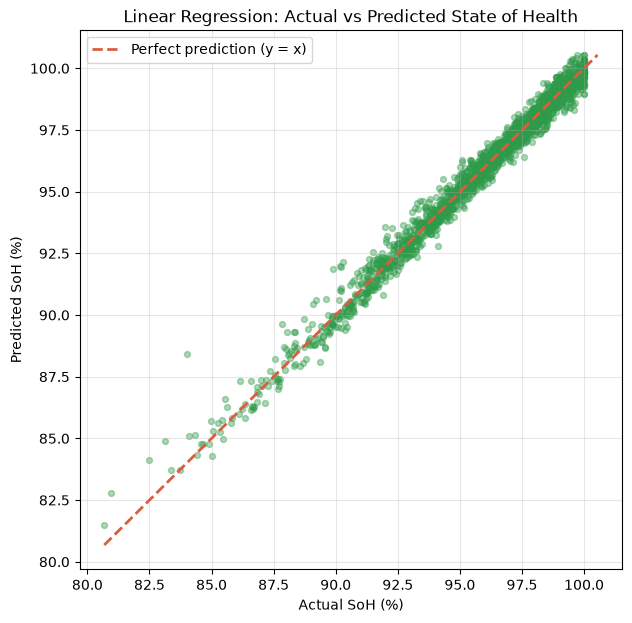

Plot saved to images/result_plot.png


In [8]:
# Create the images/ folder if it does not exist yet
os.makedirs("images", exist_ok=True)

# Draw the scatter plot
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, s=18, color="#2e9b4a")

# Diagonal (perfect prediction) reference line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "--", color="#D95D3F", linewidth=2, label="Perfect prediction (y = x)")

plt.xlabel("Actual SoH (%)")
plt.ylabel("Predicted SoH (%)")
plt.title("Linear Regression: Actual vs Predicted State of Health")
plt.legend()
plt.grid(alpha=0.3)

# Save the figure — this file is used in the project README
plt.savefig("images/result_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to images/result_plot.png")


## Summary

| Step | What we did |
| ---- | ----------- |
| Load | Read the 10,000-row CSV with pandas |
| Clean | Dropped the `Vehicle_ID` column, checked for missing values (none) |
| Encode | One-hot encoded `Battery_Type`, `Car_Model`, `Driving_Style`, `Battery_Status` |
| Split | 80% training / 20% test, `random_state=42` |
| Train | `LinearRegression().fit(X_train, y_train)` |
| Evaluate | R² and RMSE on the unseen test set |
| Visualise | Actual vs predicted scatter with the perfect line, saved as PNG |

**Final results:** R² = 0.984, RMSE = 0.41 percentage points — the model captures nearly all of the variation in EV battery health using only charging/usage data.
